In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
from sklearn.model_selection import train_test_split

from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer, DropoutLayer, BatchNormalizationLayer
from src.models_numpy.dnn.activation import ReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.metrics import accuracy
from src.models_numpy.dnn.dataset import Dataset
from src.data_processing import clean_text
from src.vectorizer import create_vectorizer
from src.models_numpy.dnn.optimizer import AdamOptimizer, SGDOptimizer

In [3]:
import nltk
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("punkt")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Preprocessamento
Aplicamos a função `clean_text` com NLTK e dividimos em treino/validação (80/20).

In [4]:
# ── Dataset completo (para treino final) ──────────────────────────────
df = pd.read_csv("../data/processed/LabelsParaHiper.csv", sep=",")

df.columns = df.columns.str.strip()
required_cols = {"Text", "Label"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"CSV tem de conter as colunas {required_cols}. Colunas encontradas: {set(df.columns)}")

label_map = {label: i for i, label in enumerate(sorted(df["Label"].unique()))}
df["label_id"] = df["Label"].map(label_map)
df["text_clean"] = df["Text"].apply(clean_text)

# Split completo — usado no treino final
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    df[["Text", "text_clean"]], df["label_id"], test_size=0.2, random_state=42, stratify=df["label_id"]
)
num_classes = len(label_map)
y_train_full_oh = np.eye(num_classes)[y_train_full.values]
y_val_full_oh   = np.eye(num_classes)[y_val_full.values]

# ── Subsample balanceado para hyperparameter search ────────────────────
# 1000 exemplos por classe (undersample — Anthropic tem ~2000, as restantes ~10000)
SAMPLE_PER_CLASS = 2000

df_hiper = (
    df.groupby("label_id", group_keys=False)
      .apply(lambda x: x.sample(n=min(SAMPLE_PER_CLASS, len(x)), random_state=42))
      .reset_index(drop=True)
)

print("=== Distribuição do subsample para hyperparameter search ===")
print(df_hiper["Label"].value_counts().sort_index())
print(f"Total: {len(df_hiper)} amostras")

X_train, X_val, y_train, y_val = train_test_split(
    df_hiper[["Text", "text_clean"]], df_hiper["label_id"],
    test_size=0.2, random_state=42, stratify=df_hiper["label_id"]
)
y_train_oh = np.eye(num_classes)[y_train.values]
y_val_oh   = np.eye(num_classes)[y_val.values]

print(f"Hyperparameter search — Treino: {X_train.shape[0]} | Validação: {X_val.shape[0]}")
print(f"Treino final disponível  — Treino: {X_train_full.shape[0]} | Validação: {X_val_full.shape[0]}")
print(f"Número de classes: {num_classes}")


=== Distribuição do subsample para hyperparameter search ===
Label
Anthropic    2000
Google       2000
Human        2000
Meta         2000
OpenAI       2000
Name: count, dtype: int64
Total: 10000 amostras
Hyperparameter search — Treino: 8000 | Validação: 2000
Treino final disponível  — Treino: 34080 | Validação: 8520
Número de classes: 5


C:\Users\Asus\AppData\Local\Temp\ipykernel_36308\1005383805.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(SAMPLE_PER_CLASS, len(x)), random_state=42))


## Espaço de Parâmetros para Random Search
- Loss functions (CategoricalCrossEntropy, FocalLossMulticlass)
- Activation functions (ReLU, Sigmoid)

In [5]:
param_grid = {
    'loss_function':       [('CategoricalCrossEntropy', CategoricalCrossEntropy)],
    'activation_function': [('ReLU', ReLUActivation)],

    'vectorizer_type':     ["forensic"], 
    'char_ngram_range':    [(2, 2), (2, 3)],
    'max_words':           [500, 1000, 2000],

    'hidden_neurons':      [[128, 64], [256, 128], [256, 128, 64]],
    'learning_rate':       [0.001, 0.005],
    'optimizer_type':      ['adam', 'sgd'],
    'epochs':              [30],
    'batch_size':          [32, 64, 128],
    'dropout_rate':        [0.3, 0.4, 0.5],
    'weight_decay':        [0.0000, 0.0001],
    'use_batchnorm':       [True, False],
    'patience':            [20],
}

print(f"Tamanho do grid: {len(param_grid)} parâmetros")
print(f"Combinações totais teóricas: {np.prod([len(v) for v in param_grid.values()])}")

Tamanho do grid: 14 parâmetros
Combinações totais teóricas: 2592


In [6]:
from itertools import product

def train_with_params(params, X_tr, y_train, X_te, y_val, num_classes, vec):
    if params.get('optimizer_type', 'adam') == 'adam':
        opt = AdamOptimizer(learning_rate=params['learning_rate'])
    else:
        opt = SGDOptimizer(learning_rate=params['learning_rate'], momentum=0.9)
        
    model = NeuralNetwork(
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        optimizer=opt,
        loss=params['loss_function'][1],
        metric=accuracy,
        early_stopping=True,
        patience=params.get('patience', 15),
        verbose=False,
    )
    
    input_dim = X_tr.shape[1]
    hidden_layers = params['hidden_neurons']
    
    model.add(DenseLayer(n_units=hidden_layers[0], input_shape=(input_dim,), 
                         l2_reg=params['weight_decay']))
    if params.get('use_batchnorm', False):
        model.add(BatchNormalizationLayer())
    model.add(params['activation_function'][1]())
    if params['dropout_rate'] > 0:
        model.add(DropoutLayer(rate=params['dropout_rate']))
    
    for i, units in enumerate(hidden_layers[1:]):
        model.add(DenseLayer(n_units=units, l2_reg=params['weight_decay']))
        if params.get('use_batchnorm', False):
            model.add(BatchNormalizationLayer())
        model.add(params['activation_function'][1]())
        if params['dropout_rate'] > 0:
            model.add(DropoutLayer(rate=params['dropout_rate'] / (i+2)))
    
    model.add(DenseLayer(n_units=num_classes, l2_reg=params['weight_decay']))
    model.add(SoftmaxActivation())
    
    dataset = Dataset(X_tr, y_train)
    val_dataset = Dataset(X_te, y_val)
    
    start_time = time.time()
    history = model.fit(dataset, val_dataset=val_dataset)
    training_time = time.time() - start_time
    
    if hasattr(model, 'best_epoch') and model.best_epoch is not None:
        best_epoch_idx = model.best_epoch - 1
        val_acc = history['val_acc'][best_epoch_idx] if 'val_acc' in history and best_epoch_idx < len(history['val_acc']) else 0
        val_loss = history['val_loss'][best_epoch_idx]
    elif 'val_loss' in history and len(history['val_loss']) > 0:
        best_epoch = np.argmin(history['val_loss'])
        val_acc = history['val_acc'][best_epoch] if 'val_acc' in history and best_epoch < len(history['val_acc']) else 0
        val_loss = history['val_loss'][best_epoch]
    else:
        val_acc = 0
        val_loss = float('inf')
    
    return {
        'model': model,
        'vectorizer': vec,
        'history': history,
        'val_acc': val_acc,
        'val_loss': val_loss,
        'training_time': training_time,
        'params': params
    }

In [7]:
print("=== A pré-computar vectorizers ===")
vectorizer_cache = {}

combos = list(product(
    param_grid['vectorizer_type'],
    param_grid['char_ngram_range'],
    param_grid['max_words']
))
print(f"Total de combinações: {len(combos)}")  # 3 × 2 × 3 = 18

for vtype, ngram, maxw in combos:
    key = (vtype, ngram, maxw)
    print(f"  A vetorizar: {key}...")
    t0 = time.time()
    vec = create_vectorizer(vtype, max_words=maxw, ngram_range=ngram)
    X_tr_v = vec.fit_transform(list(X_train['text_clean']), list(X_train['Text']))
    X_te_v = vec.transform(list(X_val['text_clean']), list(X_val['Text']))
    vectorizer_cache[key] = (vec, X_tr_v, X_te_v)
    print(f"    -> {X_tr_v.shape[1]} features em {time.time()-t0:.1f}s")

print("\nCache pronta!")

=== A pré-computar vectorizers ===
Total de combinações: 6
  A vetorizar: ('forensic', (2, 2), 500)...
    -> 737 features em 192.4s
  A vetorizar: ('forensic', (2, 2), 1000)...
    -> 1237 features em 213.6s
  A vetorizar: ('forensic', (2, 2), 2000)...
    -> 2237 features em 213.9s
  A vetorizar: ('forensic', (2, 3), 500)...
    -> 737 features em 191.7s
  A vetorizar: ('forensic', (2, 3), 1000)...
    -> 1237 features em 183.2s
  A vetorizar: ('forensic', (2, 3), 2000)...
    -> 2237 features em 181.8s

Cache pronta!


## Executar Random Search

In [8]:
from src.hyperopt import build_random_search
import random

N_ITERATIONS = 20
SEED = 42
random.seed(SEED)


results = []
best_val_acc = -1
best_model = None
best_vectorizer = None
best_history = None

print(f"=== A começar Random Search ({N_ITERATIONS} iterações) ===")

search_gen = build_random_search(param_grid, N_ITERATIONS, SEED)

for i in range(N_ITERATIONS):
    sampled_params = next(search_gen)
    
    print(f"\n[{i+1}/{N_ITERATIONS}] Testando: {sampled_params}")
    
    try:
        key = (
            sampled_params['vectorizer_type'],
            sampled_params['char_ngram_range'],
            sampled_params['max_words']
        )
        vec, X_tr_iter, X_te_iter = vectorizer_cache[key]

        result = train_with_params(
            sampled_params,
            X_tr_iter,
            y_train_oh,
            X_te_iter,
            y_val_oh,
            num_classes,
            vec=vec
        )
        
        results.append({
            'iteration': i+1,
            'val_acc': result['val_acc'],
            'val_loss': result['val_loss'],
            'time': result['training_time'],
            **sampled_params
        })
        
        if result['val_acc'] > best_val_acc:
            best_val_acc = result['val_acc']
            best_model = result['model']
            best_vectorizer = result['vectorizer']
            best_history = result['history']
            print(f"  -> Novo melhor: Val Acc: {best_val_acc:.4f}")
        else:
            print(f"  -> Val Acc: {result['val_acc']:.4f}")
    except Exception as e:
        print(f"  -> Erro: {str(e)}")
        results.append({
            'iteration': i+1,
            'error': str(e),
            **sampled_params
        })

=== A começar Random Search (20 iterações) ===

[1/20] Testando: {'loss_function': ('CategoricalCrossEntropy', <class 'src.models_numpy.dnn.losses.CategoricalCrossEntropy'>), 'activation_function': ('ReLU', <class 'src.models_numpy.dnn.activation.ReLUActivation'>), 'vectorizer_type': 'forensic', 'char_ngram_range': (2, 2), 'max_words': 500, 'hidden_neurons': [128, 64], 'learning_rate': 0.001, 'optimizer_type': 'adam', 'epochs': 30, 'batch_size': 32, 'dropout_rate': 0.3, 'weight_decay': 0.0, 'use_batchnorm': True, 'patience': 20}
  -> Novo melhor: Val Acc: 0.9870

[2/20] Testando: {'loss_function': ('CategoricalCrossEntropy', <class 'src.models_numpy.dnn.losses.CategoricalCrossEntropy'>), 'activation_function': ('ReLU', <class 'src.models_numpy.dnn.activation.ReLUActivation'>), 'vectorizer_type': 'forensic', 'char_ngram_range': (2, 2), 'max_words': 1000, 'hidden_neurons': [256, 128, 64], 'learning_rate': 0.005, 'optimizer_type': 'adam', 'epochs': 30, 'batch_size': 128, 'dropout_rate': 0

## Análise de Resultados
Vamos analisar os resultados do random search.

=== Melhores Resultados ===
    iteration  val_acc  val_loss  \
0           1   0.9870  0.046898   
4           5   0.9850  0.047881   
18         19   0.9845  0.043396   
19         20   0.9835  0.049378   
12         13   0.9830  0.047455   

                                        loss_function  \
0   (CategoricalCrossEntropy, <class 'src.models_n...   
4   (CategoricalCrossEntropy, <class 'src.models_n...   
18  (CategoricalCrossEntropy, <class 'src.models_n...   
19  (CategoricalCrossEntropy, <class 'src.models_n...   
12  (CategoricalCrossEntropy, <class 'src.models_n...   

                                  activation_function  learning_rate  \
0   (ReLU, <class 'src.models_numpy.dnn.activation...          0.001   
4   (ReLU, <class 'src.models_numpy.dnn.activation...          0.005   
18  (ReLU, <class 'src.models_numpy.dnn.activation...          0.005   
19  (ReLU, <class 'src.models_numpy.dnn.activation...          0.005   
12  (ReLU, <class 'src.models_numpy.dnn.activation..

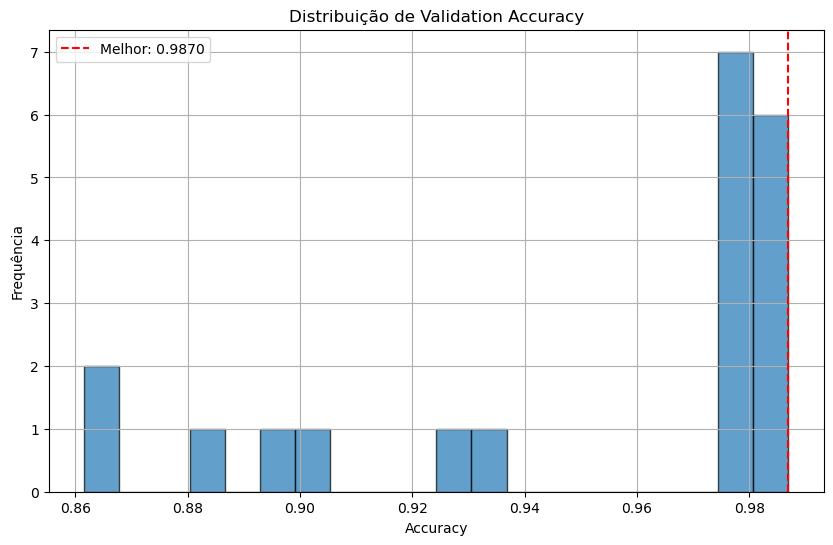


=== Correlações com Accuracy ===
val_acc          1.000000
learning_rate    0.540721
time             0.430867
max_words        0.211263
iteration        0.080453
dropout_rate    -0.090728
batch_size      -0.273911
weight_decay    -0.528884
val_loss        -0.983659
epochs                NaN
Name: val_acc, dtype: float64


In [9]:
results_df = pd.DataFrame(results)
if 'error' in results_df.columns:
    results_df = results_df[results_df['error'].isna()]

if results_df.empty or 'val_acc' not in results_df.columns:
    print("Nenhum resultado válido com 'val_acc'.")
    print("Verifique os erros da célula de treino (ex.: recursos NLTK em falta).")
else:
    print("=== Melhores Resultados ===")
    top_results = results_df.sort_values('val_acc', ascending=False).head(5)
    print(top_results[['iteration', 'val_acc', 'val_loss', 'loss_function', 'activation_function', 
                       'learning_rate', 'max_words', 'hidden_neurons']])

    plt.figure(figsize=(10, 6))
    results_df['val_acc'].hist(bins=20, edgecolor='black', alpha=0.7)
    plt.title('Distribuição de Validation Accuracy')
    plt.xlabel('Accuracy')
    plt.ylabel('Frequência')
    plt.axvline(best_val_acc, color='red', linestyle='--', label=f'Melhor: {best_val_acc:.4f}')
    plt.legend()
    plt.show()

    print("\n=== Correlações com Accuracy ===")
    numeric_cols = results_df.select_dtypes(include=[np.number]).columns
    if 'val_acc' in numeric_cols:
        correlations = results_df[numeric_cols].corr()['val_acc'].sort_values(ascending=False)
        print(correlations.head(10))

In [10]:
if best_model:
    print(f"Melhor validation accuracy: {best_val_acc:.4f}")
    print(f"Número total de modelos testados: {len(results_df)}")
    print("\nMelhores hiperparâmetros:")
    best_params = results_df.loc[results_df['val_acc'].idxmax()]
    for key, value in best_params.items():
        if key not in ['iteration', 'val_acc', 'val_loss', 'time', 'error']:
            print(f"  {key}: {value}")

Melhor validation accuracy: 0.9870
Número total de modelos testados: 20

Melhores hiperparâmetros:
  loss_function: ('CategoricalCrossEntropy', <class 'src.models_numpy.dnn.losses.CategoricalCrossEntropy'>)
  activation_function: ('ReLU', <class 'src.models_numpy.dnn.activation.ReLUActivation'>)
  vectorizer_type: forensic
  char_ngram_range: (2, 2)
  max_words: 500
  hidden_neurons: [128, 64]
  learning_rate: 0.001
  optimizer_type: adam
  epochs: 30
  batch_size: 32
  dropout_rate: 0.3
  weight_decay: 0.0
  use_batchnorm: True
  patience: 20


## Validação com Dataset Exemplos

=== Validação com Dataset Exemplos ===
Número de amostras de teste: 125
Distribuição de classes:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64

Accuracy no dataset exemplos: 0.2720
Accuracy na validação interna: 0.9870
Diferença: -0.7150

=== Relatório de Classificação (Dataset Exemplos) ===
              precision    recall  f1-score   support

   Anthropic       0.37      0.48      0.42        23
      Google       0.44      0.44      0.44        16
       Human       1.00      0.04      0.07        52
        Meta       0.00      0.00      0.00        17
      OpenAI       0.18      0.82      0.30        17

    accuracy                           0.27       125
   macro avg       0.40      0.36      0.25       125
weighted avg       0.56      0.27      0.20       125



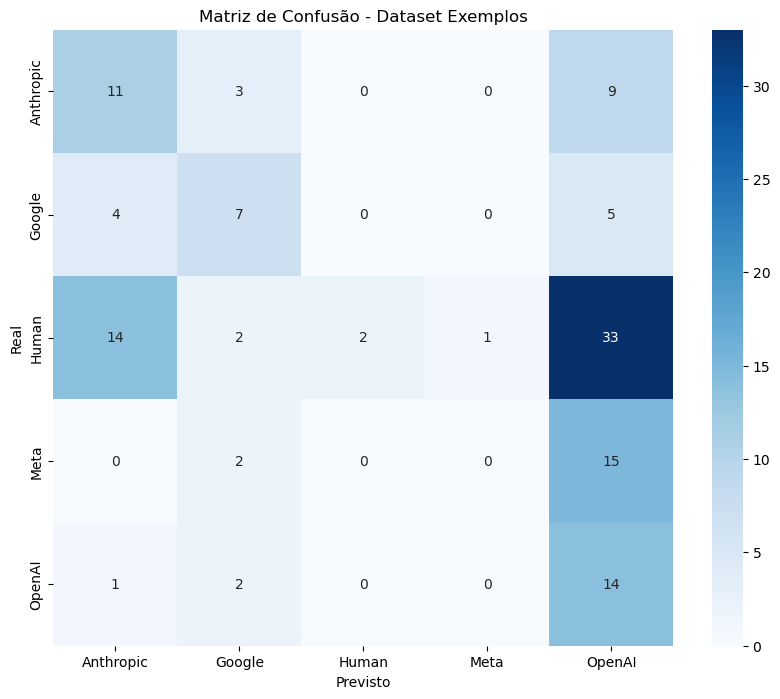

In [11]:
if best_model:
    df_test = pd.read_csv("../data/raw/dataset-exemplos.csv", sep=";")
    
    df_test['label_id'] = df_test['Label'].map(label_map)
    df_test['text_clean'] = df_test['Text'].apply(clean_text)
    
    X_test = best_vectorizer.transform(
        list(df_test['text_clean']),
        list(df_test['Text'])
    )
    class_counts = df['label_id'].value_counts().sort_index().values
    class_weights = len(df) / (num_classes * class_counts)
    class_weights = class_weights / class_weights.sum()
    y_pred_probs = best_model.forward_propagation(X_test, training=False)
    y_pred_weighted = y_pred_probs * class_weights
    y_pred = np.argmax(y_pred_weighted, axis=1)
    y_true = df_test['label_id'].values
    
    print("=== Validação com Dataset Exemplos ===")
    print(f"Número de amostras de teste: {len(df_test)}")
    print(f"Distribuição de classes:\n{df_test['Label'].value_counts()}")
    print()
    
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    
    test_acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy no dataset exemplos: {test_acc:.4f}")
    print(f"Accuracy na validação interna: {best_val_acc:.4f}")
    print(f"Diferença: {test_acc - best_val_acc:.4f}")
    print()
    
    print("=== Relatório de Classificação (Dataset Exemplos) ===")
    print(classification_report(y_true, y_pred, target_names=list(label_map.keys())))
    
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_map.keys(), yticklabels=label_map.keys())
    plt.title('Matriz de Confusão - Dataset Exemplos')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()
else:
    print("Nenhum modelo treinado. Execute as células anteriores primeiro.")

#     # Salvar melhor modelo
#     best_model.save("../saved_models/DNN_best_model.npz")
#     print("\nMelhor modelo salvo em '../saved_models/DNN_best_model.npz'")
    
#     # Salvar também o vectorizer
#     import pickle
#     with open('../saved_models/DNN_best_vectorizer.pkl', 'wb') as f:
#         pickle.dump(best_vectorizer, f)
#     print("Vectorizer salvo em '../saved_models/DNN_best_vectorizer.pkl'")
# else:
#     print("Nenhum modelo treinado com sucesso.")

In [13]:
# ── Treino final com os melhores hiperparâmetros e dataset completo ──────
# Vectorizer fitted nos dados completos
final_vec = create_vectorizer("forensic", max_words=500, ngram_range=(2, 2))
X_tr_final = final_vec.fit_transform(
    list(X_train_full['text_clean']), list(X_train_full['Text'])
)
X_te_final = final_vec.transform(
    list(X_val_full['text_clean']), list(X_val_full['Text'])
)

y_train_final_oh = y_train_full_oh
y_val_final_oh   = y_val_full_oh

# Melhores hiperparâmetros encontrados
best_params_final = {
    'loss_function':       ('CategoricalCrossEntropy', CategoricalCrossEntropy),
    'activation_function': ('ReLU', ReLUActivation),
    'hidden_neurons':      [128, 64],
    'learning_rate':       0.001,
    'optimizer_type':      'adam',
    'epochs':              30,        # mais epochs no treino final
    'batch_size':          32,
    'dropout_rate':        0.3,
    'weight_decay':        0.0,
    'use_batchnorm':       True,
    'patience':            20,
}

final_result = train_with_params(
    best_params_final,
    X_tr_final, y_train_final_oh,
    X_te_final, y_val_final_oh,
    num_classes, vec=final_vec
)

best_model      = final_result['model']
best_vectorizer = final_result['vectorizer']
best_val_acc    = final_result['val_acc']

print(f"Treino final — Val Acc: {best_val_acc:.4f}")

Treino final — Val Acc: 0.9912


In [ ]:
# Teste no dataset-exemplos com o modelo treinado na célula 17
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

if best_model is None or best_vectorizer is None:
    raise ValueError("Executa primeiro a célula 17 para treinar o modelo final.")

df_exemplos = pd.read_csv("../data/raw/dataset-exemplos.csv", sep=";")
df_exemplos.columns = df_exemplos.columns.str.strip()

required_cols = {"Text", "Label"}
if not required_cols.issubset(df_exemplos.columns):
    raise ValueError(
        f"dataset-exemplos.csv tem de conter {required_cols}. Colunas encontradas: {set(df_exemplos.columns)}"
    )

# Usa apenas Text para inferência
df_exemplos["text_clean"] = df_exemplos["Text"].apply(clean_text)
df_exemplos["label_id"] = df_exemplos["Label"].map(label_map)

unknown_mask = df_exemplos["label_id"].isna()
if unknown_mask.any():
    print(f"Aviso: {unknown_mask.sum()} linhas com labels fora do label_map foram removidas.")
    df_exemplos = df_exemplos.loc[~unknown_mask].copy()

df_exemplos["label_id"] = df_exemplos["label_id"].astype(int)

X_exemplos = best_vectorizer.transform(
    list(df_exemplos["text_clean"]),
    list(df_exemplos["Text"])
)

y_pred_probs = best_model.forward_propagation(X_exemplos, training=False)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = df_exemplos["label_id"].values

id_to_label = {v: k for k, v in label_map.items()}
df_exemplos["Label_Predita"] = [id_to_label[idx] for idx in y_pred]
df_exemplos["Correto"] = (df_exemplos["Label_Predita"] == df_exemplos["Label"])

acc = accuracy_score(y_true, y_pred)
print("=== Teste no dataset-exemplos (modelo da célula 17) ===")
print(f"Amostras avaliadas: {len(df_exemplos)}")
print(f"Accuracy: {acc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=list(label_map.keys())))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_map.keys(), yticklabels=label_map.keys()
)
plt.title("Matriz de Confusao - dataset-exemplos")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print("\nAmostra de previsoes:")
print(df_exemplos[["Text", "Label", "Label_Predita", "Correto"]].head(10))